<a href="https://colab.research.google.com/github/sonky20/sonky/blob/master/4%EC%9D%BC%EC%B0%A8_%EC%9D%B4%EC%A7%84%EB%B6%84%EB%A5%98%EB%AA%A8%EB%8D%B8%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#전처리와 평가를 위한 sklearn 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler

#파이토치 라이브러리
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [2]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
  #데이터 텐서로 변환
  x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
  x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

  #TensorDataset 생성: 텐서 데이터 세트로 합치기
  train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
  val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

  #DataLoader 생성
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  return train_loader, x_val_tensor, y_val_tensor

def train(dataloader, model, loss_fn, optimizer, device):
  size = len(dataloader.dataset) #전체 데이터 세트의 크기
  num_batches = len(dataloader) #배치의 개수
  tr_loss = 0

  model.train()
  for x, y in dataloader: #배치 단위로 로딩
    x, y = x.to(device), y.to(device) #디바이스 지정
    #Feed Forward(오차 순전파)
    pred = model(x)
    loss = loss_fn(pred, y)
    tr_loss += loss

    #Backpropagation(오차 역전파)
    loss.backward() #역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
    optimizer.step() #옵티마이저가 모델의 파라미터를 업데이트
    optimizer.zero_grad() #옵티마이저의 기울기값 초기화

  tr_loss /= num_batches #모든 배치의 오차 평균
  return tr_loss.item()

def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
  model.eval() #모델을 평가 모드로 설정
  with torch.no_grad(): #평가 과정에서 기울기를 계산하지 않도록 설정
    x, y = x_val_tensor.to(device), y_val_tensor.to(device)
    pred = model(x)
    eval_loss = loss_fn(pred, y) #에측값 pred와 목표값 y 사이의 오차 계산
    print(eval_loss, eval_loss.item())
  return eval_loss.item(), pred

def dl_learning_curve(tr_loss_list, val_loss_list):
  epochs = list(range(1, len(tr_loss_list)+1)) #에포크 수 계산
  plt.plot(epochs, tr_loss_list, label='train_err', marker='.') #학습 오차 그래프
  plt.plot(epochs, val_loss_list, label='val_err', marker='.') #검증 오차 그래프
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend()
  plt.grid()
  plt.show()



In [3]:
path = "https://bit.ly/titanic_simple_csv"
data = pd.read_csv(path)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


In [4]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=data)

https://docs.google.com/spreadsheets/d/1VQNJwPk4Q70gqiYGDmxt4hPx0yDa8kGz5J9JY66Q7TI/edit#gid=0


In [5]:
target = 'Survived'
features = ['Sex', 'Age', 'Fare']
x = data.loc[:, features]
y = data.loc[:, target]

x = pd.get_dummies(x, columns=['Sex'], drop_first=True)
x.head()

,Age,Fare,Sex_male
0,22.0,7.2500,True
1,38.0,71.2833,False
2,26.0,7.9250,False
3,35.0,53.1000,False
4,35.0,8.0500,True


In [6]:
#데이터 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)

#스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

#make_DataSet 입력을 위해 y_train, y_val를 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values

train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

#첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
  print(f"Shape of x [rows, columns]: {x.shape}")
  print(f"Shape of y: {y.shape}")
  break



Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1])


In [7]:
n_feature = x.shape[1]
#모델 구조 설계
model = nn.Sequential(nn.Linear(n_feature, 1), nn.Sigmoid())
model.to(device)

loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)

epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
  #리스트에 loss 추가
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"Epoch {t+1}, train loss: {tr_loss:4f}, val loss: {val_loss:4f}")

tensor(0.6731) 0.673149585723877
Epoch 1, train loss: 0.677374, val loss: 0.673150
tensor(0.6581) 0.6580844521522522
Epoch 2, train loss: 0.656784, val loss: 0.658084
tensor(0.6442) 0.6441968679428101
Epoch 3, train loss: 0.639798, val loss: 0.644197
tensor(0.6313) 0.631303071975708
Epoch 4, train loss: 0.626279, val loss: 0.631303
tensor(0.6191) 0.61911940574646
Epoch 5, train loss: 0.611817, val loss: 0.619119
tensor(0.6085) 0.6084885001182556
Epoch 6, train loss: 0.598568, val loss: 0.608489
tensor(0.5997) 0.5996501445770264
Epoch 7, train loss: 0.584370, val loss: 0.599650
tensor(0.5924) 0.5924078226089478
Epoch 8, train loss: 0.578099, val loss: 0.592408
tensor(0.5840) 0.5839815139770508
Epoch 9, train loss: 0.570396, val loss: 0.583982
tensor(0.5770) 0.5769541263580322
Epoch 10, train loss: 0.556734, val loss: 0.576954
tensor(0.5716) 0.5715643763542175
Epoch 11, train loss: 0.551975, val loss: 0.571564
tensor(0.5667) 0.5667394995689392
Epoch 12, train loss: 0.544460, val loss: 0.

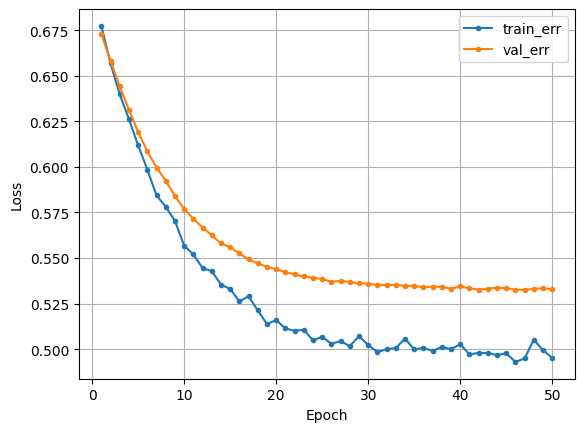

In [8]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [9]:
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
print(pred.numpy()[:5])

tensor(0.5328) 0.5328458547592163
[[0.18614627]
 [0.7472115 ]
 [0.2533991 ]
 [0.7722089 ]
 [0.18549715]]


In [10]:
pred = np.where(pred.numpy() > 0.5, 1, 0)
print(pred[:5])

[[0]
 [1]
 [0]
 [1]
 [0]]


In [11]:
print(confusion_matrix(y_val_ts.numpy(), pred))

[[108  20]
 [ 31  55]]


In [12]:
print(classification_report(y_val_ts.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.78      0.84      0.81       128
         1.0       0.73      0.64      0.68        86

    accuracy                           0.76       214
   macro avg       0.76      0.74      0.75       214
weighted avg       0.76      0.76      0.76       214



In [13]:
path = "https://bit.ly/titanic_simple_csv"
data = pd.read_csv(path)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


In [14]:
#모델링에서 불필요한 열 제거
data = data.drop(['PassengerId', 'Name'], axis=1)

#x,y 분할
target = 'Survived'
x = data.drop(target, axis=1)
y = data.loc[:, target]

#가변수화
x = pd.get_dummies(x, columns=['Pclass', 'Sex', 'Embarked'], drop_first=True)

#train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.1)

#스케일러 선언
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

#make_DataSet 입력을 위해 y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values

train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


In [27]:
n_feature = x.shape[1]
print(n_feature)

#모델 구조 설계
model = nn.Sequential(nn.Linear(n_feature, 7), nn.ReLU(),
                      nn.Linear(7, 1), nn.Sigmoid())
model.to(device)
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)

7


In [28]:
epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
  #리스트에 loss 추가
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"Epoch {t+1}, train loss: {tr_loss:4f}, val loss: {val_loss:4f}")

tensor(0.6088) 0.6088021397590637
Epoch 1, train loss: 0.661456, val loss: 0.608802
tensor(0.5400) 0.5399635434150696
Epoch 2, train loss: 0.602021, val loss: 0.539964
tensor(0.4866) 0.4866234362125397
Epoch 3, train loss: 0.541989, val loss: 0.486623
tensor(0.4596) 0.4595838785171509
Epoch 4, train loss: 0.502070, val loss: 0.459584
tensor(0.4483) 0.4483104348182678
Epoch 5, train loss: 0.481578, val loss: 0.448310
tensor(0.4339) 0.4338502287864685
Epoch 6, train loss: 0.473805, val loss: 0.433850
tensor(0.4317) 0.4317152798175812
Epoch 7, train loss: 0.466461, val loss: 0.431715
tensor(0.4267) 0.4267388880252838
Epoch 8, train loss: 0.461260, val loss: 0.426739
tensor(0.4258) 0.4257904291152954
Epoch 9, train loss: 0.460390, val loss: 0.425790
tensor(0.4175) 0.4175421893596649
Epoch 10, train loss: 0.457750, val loss: 0.417542
tensor(0.4144) 0.41436517238616943
Epoch 11, train loss: 0.454376, val loss: 0.414365
tensor(0.4114) 0.4113810360431671
Epoch 12, train loss: 0.450937, val los

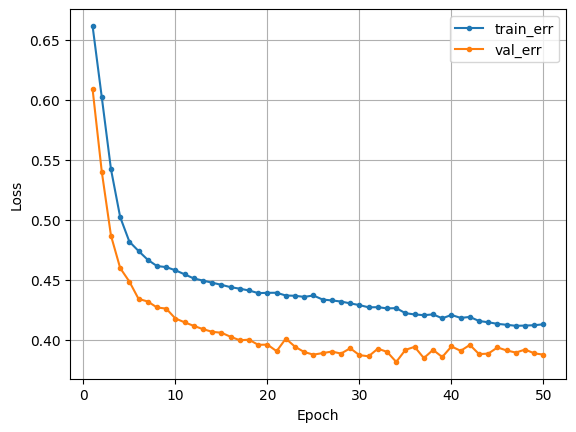

In [29]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [30]:
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
#print(pred.numpy()[:5])

pred = np.where(pred.numpy() > 0.5, 1, 0)
#print(pred[:5])

print(confusion_matrix(y_val_ts.numpy(), pred))

tensor(0.3874) 0.3873845040798187
[[43  3]
 [ 8 18]]


In [31]:
print(classification_report(y_val_ts.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.84      0.93      0.89        46
         1.0       0.86      0.69      0.77        26

    accuracy                           0.85        72
   macro avg       0.85      0.81      0.83        72
weighted avg       0.85      0.85      0.84        72

